In [1]:
import xarray as xr
import rasterio
import os

In [2]:
def joint_era5_xr(folder):

    datasets = []
    all_files = os.listdir(folder)

    for i in range(len(all_files)):
        
        xr_data = xr.open_dataset(f"{folder}{all_files[i]}")
        
        if i < len(all_files) - 1:
            xr_data = xr_data.isel(valid_time=slice(None, -25))
        
        datasets.append(xr_data)
        
    ds = xr.concat(datasets, dim = "valid_time").drop_vars(["number","expver"])
    
    ds = ds.rename_vars({"latitude":"lat",
                        "longitude":"lon",
                        "valid_time":"time"})
    ds = ds.rename({"latitude":"lat","longitude":"lon"})
    
    return ds

In [3]:
era5_2000_2024 = joint_era5_xr("C:/Users/msali/Desktop/Python/Nitrates_WTD_PI/data/weather/era5land/")

C:\Users\msali\AppData\Local\Temp\ipykernel_16504\3453165731.py:20: UserWarning: rename 'latitude' to 'lat' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  ds = ds.rename({"latitude":"lat","longitude":"lon"})
C:\Users\msali\AppData\Local\Temp\ipykernel_16504\3453165731.py:20: UserWarning: rename 'longitude' to 'lon' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  ds = ds.rename({"latitude":"lat","longitude":"lon"})


In [4]:
era5_2000_2024 = era5_2000_2024.rio.write_crs("epsg:4326")

In [5]:
era5_2000_2024

<xarray.Dataset> Size: 1GB
Dimensions:      (valid_time: 201611, lat: 12, lon: 16)
Coordinates:
  * time         (valid_time) datetime64[ns] 2MB 2001-01-01 ... 2024-01-01T23...
  * lat          (lat) float64 96B 45.35 45.25 45.15 45.05 ... 44.45 44.35 44.25
  * lon          (lon) float64 128B 6.625 6.725 6.825 ... 7.926 8.026 8.126
    spatial_ref  int32 4B 0
Dimensions without coordinates: valid_time
Data variables:
    t2m          (valid_time, lat, lon) float32 155MB 259.5 260.0 ... 274.9
    smlt         (valid_time, lat, lon) float32 155MB 0.0 0.0 ... 2.969e-08
    swvl1        (valid_time, lat, lon) float32 155MB 0.4146 0.4137 ... 0.3679
    swvl2        (valid_time, lat, lon) float32 155MB 0.4161 0.4159 ... 0.3668
    swvl3        (valid_time, lat, lon) float32 155MB 0.4063 0.4102 ... 0.3724
    swvl4        (valid_time, lat, lon) float32 155MB 0.4728 0.4695 ... 0.3516
    pev          (valid_time, lat, lon) float32 155MB -0.0002383 ... -0.002434
    tp           (valid_time, lat, lon) float32 155MB 8.218e-05 ... 8.523e-07
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-08-28T22:29 GRIB to CDM+CF via cfgrib-0.9.1...

In [6]:
era5_2000_2024_W = era5_2000_2024.resample(time="W", label = "left").mean()
era5_2000_2024_W

<xarray.Dataset> Size: 7MB
Dimensions:      (time: 1201, lat: 12, lon: 16)
Coordinates:
  * lat          (lat) float64 96B 45.35 45.25 45.15 45.05 ... 44.45 44.35 44.25
  * lon          (lon) float64 128B 6.625 6.725 6.825 ... 7.926 8.026 8.126
    spatial_ref  int32 4B 0
  * time         (time) datetime64[ns] 10kB 2000-12-31 2001-01-07 ... 2023-12-31
Data variables:
    t2m          (time, lat, lon) float32 922kB 266.5 265.4 ... 276.1 277.4
    smlt         (time, lat, lon) float32 922kB 0.0 0.0 ... 1.665e-07 1.967e-08
    swvl1        (time, lat, lon) float32 922kB 0.4137 0.4127 ... 0.3655 0.3739
    swvl2        (time, lat, lon) float32 922kB 0.4149 0.4147 ... 0.3608 0.3664
    swvl3        (time, lat, lon) float32 922kB 0.4052 0.4087 ... 0.3753 0.3726
    swvl4        (time, lat, lon) float32 922kB 0.4718 0.4686 ... 0.3594 0.3516
    pev          (time, lat, lon) float32 922kB -6.539e-05 ... -0.00117
    tp           (time, lat, lon) float32 922kB 0.006091 0.005877 ... 0.00021
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-08-28T22:29 GRIB to CDM+CF via cfgrib-0.9.1...

In [7]:
era5_2000_2024_W = era5_2000_2024_W.rio.write_crs("epsg:4326")

In [8]:
era5_2000_2024_W.isnull().any()

<xarray.Dataset> Size: 12B
Dimensions:      ()
Coordinates:
    spatial_ref  int32 4B 0
Data variables:
    t2m          bool 1B False
    smlt         bool 1B False
    swvl1        bool 1B False
    swvl2        bool 1B False
    swvl3        bool 1B False
    swvl4        bool 1B False
    pev          bool 1B False
    tp           bool 1B False

# Plot

In [9]:
import shapely
from shapely.geometry import box
import matplotlib
import matplotlib.pyplot as plt

roi_box = box(6.626637251395974, 44.31072084879872, 8.028928811017375 , 45.26528455094999)

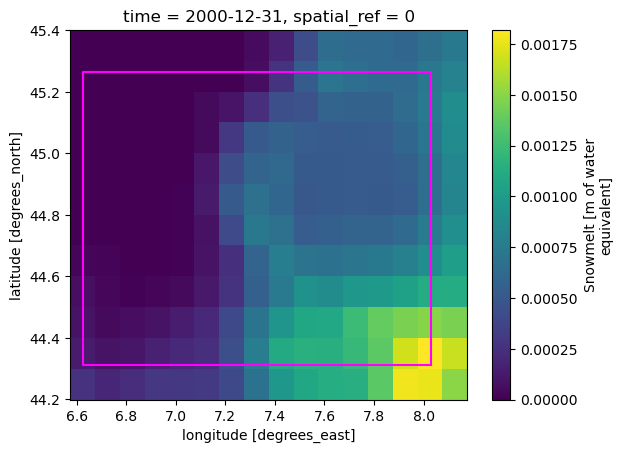

In [10]:
fig, ax = plt.subplots()

era5_2000_2024_W["smlt"][0].plot(ax = ax)
ax.plot(*roi_box.exterior.xy, label = "bbox", color = "magenta")

# DTM

In [11]:
import rioxarray

In [12]:
dir_main = "C:/Users/msali/Desktop/Python/Nitrates_WTD_PI/"
dir_data = f"{dir_main}data/"
dir_gw = f"{dir_data}groundwater/"
dir_snow = f"{dir_data}snowpack/"
dir_geodata_gw = f"{dir_gw}shapefile_raster_groundwater/"
dir_geodata_roi = f"{dir_data}shapefile_raster/"

In [13]:
ds_arpa_orography = rioxarray.open_rasterio('C:/Users/msali/Desktop/Python/Nitrates_WTD_PI/data/shapefile_raster/roi/dtm_ROI_arpa_weather.nc')

In [14]:
eu_dtm = rioxarray.open_rasterio(f"{dir_geodata_roi}eu_dtm/10_DEM_y40x0.tif", engine='fiona')
eu_dtm = eu_dtm.rio.reproject("epsg:4326")

In [15]:
eu_dtm_era5 = eu_dtm.interp(y=era5_2000_2024_W.lat, x=era5_2000_2024_W.lon, method="linear").drop_vars(["x","y"])
eu_dtm_era5 = eu_dtm_era5.rename({"lat":"y","lon":"x"})

In [16]:
eu_dtm_era5

<xarray.DataArray (band: 1, y: 12, x: 16)> Size: 2kB
array([[[2409.10761719, 2652.78967969, 2090.36951855, 2504.99671484,
         1857.2745752 , 2758.93001953, 1550.09990625, 1638.65249609,
         1666.23660547, 1217.31667676,  392.40832764,  304.97692358,
          355.0474375 ,  227.42933533,  288.1830957 ,  191.69981934],
        [2875.95332031, 1983.50369238, 1744.89089063, 2129.629625  ,
         2217.8059668 , 3083.63594727, 2262.87513672, 1424.70077344,
          892.53180029,  404.92559937,  361.67582764,  234.35370703,
          220.01968237,  218.41478918,  192.35740454,  163.77319458],
        [2318.74731445, 2634.91276953, 2628.150125  , 2561.22103906,
          565.30191309,  786.5189502 , 1259.55053125,  890.48687891,
          906.8110249 ,  309.48313281,  272.99186035,  229.54094275,
          189.33658093,  220.72155688,  215.97180469,  220.83039856],
        [2288.5878418 , 1741.95549121, 1582.32816895, 2242.1499707 ,
         1586.12687109, 2132.12287109, 1644.33258301,  631.88380859,
          451.68002808,  317.79119751,  264.55937744,  379.43359839,
          323.74241528,  305.80357471,  259.65609766,  209.27432617],
        [2264.22929687, 2484.29002148, 1889.59431738, 2587.47518945,
         2083.83353711, 1403.31176269,  733.2075166 ,  565.05223779,
          276.14163062,  247.94230127,  230.58975708,  224.49088477,
          246.56827783,  252.53115356,  237.87339185,  229.82189392],
...
        [1091.32814941, 2141.85760938, 2615.88321094, 2923.36541992,
         2433.18246094, 2466.38816406, 1608.12096387,  468.82154883,
          318.76908887,  333.56755005,  312.71348511,  306.64490234,
          233.01554175,  435.52484351,  451.93549683,  592.67027344],
        [1762.35310059, 2603.11174805, 2530.99491211, 2854.35450977,
         2645.41717383, 2276.5125    , 1551.6808125 , 1018.26153467,
          584.12568066,  428.64726343,  374.17089111,  380.30263818,
          348.34487158,  260.05565552,  534.05418848,  525.83845215],
        [2569.10097656, 1845.17007813, 2050.54328223, 2303.34458398,
         2007.08670703, 1855.04908691, 1346.01555957,  898.82191992,
          563.88430518,  482.32128882,  403.13344604,  410.66348779,
          311.32994263,  539.88502686,  688.86248682,  357.24603149],
        [1336.31833496, 2211.03236719, 2237.71311133, 2642.40126758,
         1500.5939375 , 2402.57209961, 2077.57727734, 1421.18452637,
          968.37409766,  566.19227783,  509.69026855,  598.58489893,
          552.1274248 ,  599.74804053,  696.30387109,  775.34525879],
        [1470.62304688, 2645.45796875, 2042.33874023, 1277.18276855,
         1990.88652344, 2223.73813477, 2433.67154297, 1111.63346191,
         1525.5957959 ,  976.87697021, 1559.7996582 , 1347.65551758,
         1171.71859863, 1292.64383301,  558.91046875,  814.95982666]]])
Coordinates:
  * band         (band) int32 4B 1
    spatial_ref  int32 4B 0
  * y            (y) float64 96B 45.35 45.25 45.15 45.05 ... 44.45 44.35 44.25
  * x            (x) float64 128B 6.625 6.725 6.825 6.925 ... 7.926 8.026 8.126
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    _FillValue:     nan

In [17]:
eu_dtm_era5 = eu_dtm_era5.rio.reproject("epsg:4326")

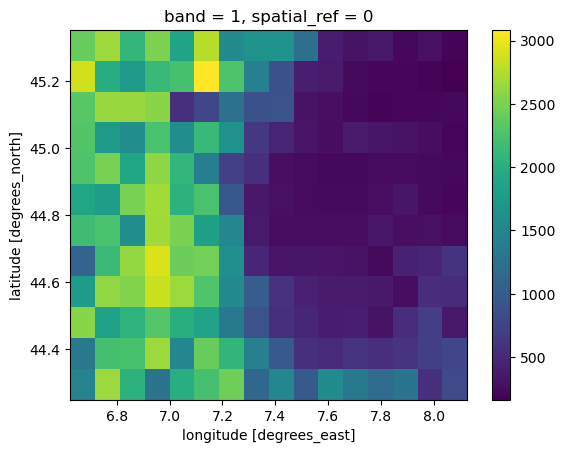

In [18]:
eu_dtm_era5.plot()

In [19]:
ds_arpa_orography

<xarray.DataArray 'orog' (time: 1, y: 9, x: 12)> Size: 432B
[108 values with dtype=float32]
Coordinates:
  * x            (x) float64 96B 6.688 6.812 6.938 7.062 ... 7.812 7.938 8.062
  * y            (y) float64 72B 45.31 45.19 45.06 44.94 ... 44.56 44.44 44.31
  * time         (time) object 8B 1957-12-02 12:00:00
    spatial_ref  int32 4B 0
Attributes: (12/17)
    lat#axis:                Y
    lat#long_name:           latitude
    lat#standard_name:       latitude
    lat#units:               degrees_north
    lat#_FillValue:          nan
    lon#axis:                X
    ...                      ...
    NETCDF_DIM_time_DEF:     [1. 6.]
    NETCDF_DIM_time_VALUES:  1
    units:                   m
    _FillValue:              nan
    scale_factor:            1.0
    add_offset:              0.0

In [20]:
eu_dtm_era5.values.shape

(1, 12, 16)

In [21]:
ds_arpa_orography.values.shape

(1, 9, 12)

# Saving

In [ ]:
era5_2000_2024_W.drop_vars("spatial_ref").to_netcdf("C:/Users/msali/Desktop/Python/Nitrates_WTD_PI/data/weather/era5land_2000_2024.nc")

In [ ]:
era5_2000_2024_W.drop_vars("spatial_ref").to_netcdf("C:/Users/msali/Desktop/Python/Nitrates_WTD_PI/data/weather/era5land_2000_2024_weekly.nc")

In [ ]:
eu_dtm_era5.drop_vars("spatial_ref").to_netcdf("C:/Users/msali/Desktop/Python/Nitrates_WTD_PI/data/weather/era5land_dtm.nc")